В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
import numpy as np


drive.mount('/content/drive')
train_df = pd.read_csv('drive/MyDrive/Colab Notebooks/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [3]:
train_df, val_df = train_test_split(train_df, test_size= 0.2, random_state= 42, stratify= train_df["Exited"])

In [4]:
train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,7180,15652218.0,Mays,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0
10393,10393,15592937.0,Ch'eng,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,0.0
80,80,15774586.0,Ch'in,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0
3365,3365,15780572.0,K?,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0
12236,12236,15642099.0,Trevisani,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,9493,15711299.0,Onyekachi,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,0.0
8463,8463,15778418.0,Tsao,673.0,France,Female,40.0,1.0,0.00,1.0,1.0,1.0,47832.82,0.0
8143,8143,15585192.0,Hsia,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,0.0
11512,11512,15694450.0,Onuora,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95,0.0


In [5]:
val_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6490,6490,15794345.0,Pirozzi,714.0,Germany,Male,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32,1.0
3646,3646,15617348.0,Ritchie,593.0,France,Male,41.0,5.0,0.00,2.0,1.0,1.0,38196.24,0.0
5306,5306,15787907.0,Hs?eh,731.0,France,Female,38.0,2.0,0.00,2.0,0.0,1.0,116971.05,0.0
652,652,15803378.0,Onio,673.0,France,Female,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76,0.0
2627,2627,15772423.0,Genovesi,678.0,Spain,Female,30.0,4.0,0.00,2.0,1.0,0.0,143681.85,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10550,10550,15635388.0,Hsia,678.0,France,Male,38.0,4.0,0.00,2.0,1.0,0.0,133535.29,0.0
8866,8866,15589715.0,Ting,753.0,France,Male,54.0,6.0,0.00,1.0,1.0,0.0,177065.24,1.0
3244,3244,15682890.0,Okwuadigbo,678.0,Spain,Male,32.0,5.0,0.00,2.0,1.0,0.0,176712.59,0.0
12441,12441,15690188.0,Aitken,724.0,Spain,Male,33.0,5.0,138162.41,1.0,1.0,0.0,105720.09,0.0


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [6]:
input_cols = list(train_df.columns)[3:-1]
target_cols = "Exited"
print(target_cols)
print(input_cols)

Exited
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [7]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_cols].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [8]:
numeric_cols = train_inputs.select_dtypes(include= np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include= "object").columns.tolist()

In [9]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

In [10]:
train_df[:5]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,7180,15652218.0,Mays,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0
10393,10393,15592937.0,Ch'eng,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,0.0
80,80,15774586.0,Ch'in,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0
3365,3365,15780572.0,K?,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0
12236,12236,15642099.0,Trevisani,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0.0


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [11]:
val_inputs[numeric_cols].isna().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [12]:
train_inputs[numeric_cols].isna().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


у наборах немає пропущених значень, тому інпутацію ми не проводимо

In [13]:
train_inputs[numeric_cols][:5]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


Масштабувати будемо колонки CreditScore, Age, Tenure, Balance, NumofProducts, EstimatedSalary\
HasCrCard та Is ActiveMember це бінарні колонки, тому їх не масштабуємо.

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
scaler.fit(train_inputs[[col for col in numeric_cols if col not in ['HasCrCard', 'IsActiveMember']]])

StandardScaler()

In [17]:
scale_cols = [col for col in numeric_cols if col not in ['HasCrCard', 'IsActiveMember']]

train_inputs[scale_cols] = scaler.transform(train_inputs[scale_cols])
val_inputs[scale_cols] = scaler.transform(val_inputs[scale_cols])


In [18]:
train_inputs[numeric_cols][:5]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,1.0,1.0,0.569450
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,1.0,0.0,0.603803
80,0.638166,-0.330288,0.350096,1.223831,0.769304,1.0,0.0,1.238026
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,0.0,1.0,-1.457116
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,1.0,1.0,0.670629


In [19]:
val_inputs[numeric_cols][:5]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
6490,0.762592,1.021379,-1.447264,1.214543,4.524299,1.0,1.0,-0.988144
3646,-0.910252,0.406985,-0.009376,-0.717950,0.769304,1.0,1.0,-1.750392
5306,0.997620,0.038348,-1.087792,-0.717950,0.769304,0.0,1.0,-0.022404
652,0.195761,0.652742,-0.368848,1.881867,-1.108193,0.0,1.0,-0.139723
2627,0.264887,-0.944682,-0.368848,-0.717950,0.769304,1.0,0.0,0.563519


Тепер переглянемо категоріальні колонки та спробуємо їх закодувати

In [20]:
train_df[categorical_cols].nunique(), val_df[categorical_cols].nunique()

(Geography    3
 Gender       2
 dtype: int64,
 Geography    3
 Gender       2
 dtype: int64)

Маємо дві категоріальні колонки, так як колонки ID, CustomerId, Surname буди виключені з набору бо не мають ніякого сенсу.
Gender це бінарна колонка - кодуємо 1 та 0, а Geography - OneHot

In [21]:
train_inputs[categorical_cols], val_inputs[categorical_cols]

(      Geography  Gender
 7180     France    Male
 10393    France  Female
 80      Germany    Male
 3365      Spain    Male
 12236    France    Male
 ...         ...     ...
 9493     France  Female
 8463     France  Female
 8143     France    Male
 11512     Spain    Male
 9360     France  Female
 
 [12000 rows x 2 columns],
       Geography  Gender
 6490    Germany    Male
 3646     France    Male
 5306     France  Female
 652      France  Female
 2627      Spain  Female
 ...         ...     ...
 10550    France    Male
 8866     France    Male
 3244      Spain    Male
 12441     Spain    Male
 3024     France    Male
 
 [3000 rows x 2 columns])

In [22]:
train_inputs['Gender'] = (train_inputs['Gender'] == 'Male').astype(int)
val_inputs['Gender'] = (val_inputs['Gender'] == 'Male').astype(int)

In [23]:
train_inputs['Gender'][:5], val_inputs['Gender'][:5]

(7180     1
 10393    0
 80       1
 3365     1
 12236    1
 Name: Gender, dtype: int64,
 6490    1
 3646    1
 5306    0
 652     0
 2627    0
 Name: Gender, dtype: int64)

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
encoder = OneHotEncoder(sparse_output= False, handle_unknown= 'ignore')

In [26]:
encoder.fit(train_inputs[['Geography']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [27]:
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object)]

In [28]:
encoded_cols_Geography = list(encoder.get_feature_names_out(["Geography"]))
encoded_cols_Geography_val = list(encoder.get_feature_names_out(["Geography"]))

In [29]:
encoder.transform(train_inputs[['Geography']])[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [30]:
encoded_Geography = encoder.transform(train_inputs[['Geography']])
encoded_Geography_val = encoder.transform(val_inputs[['Geography']])

In [31]:
print(encoded_Geography[:5])
print(encoded_Geography_val[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [32]:
gender_array = train_inputs['Gender'].values.reshape(-1, 1)
gender_array_val = val_inputs['Gender'].values.reshape(-1, 1)


In [33]:
geo_df = pd.DataFrame(encoded_Geography, columns=encoded_cols_Geography, index=train_inputs.index)
train_inputs = pd.concat([train_inputs, geo_df], axis=1)

geo_df_val = pd.DataFrame(encoded_Geography_val, columns=encoded_cols_Geography_val, index=val_inputs.index)
val_inputs = pd.concat([val_inputs, geo_df_val], axis=1)

In [34]:
from IPython.display import display

display(train_inputs.head(5))
display(val_inputs.head(5))


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7180,0.320187,France,1,-0.944682,-1.447264,1.475464,-1.108193,1.0,1.0,0.569450,1.0,0.0,0.0
10393,0.347838,France,0,0.161227,-1.087792,2.254434,-1.108193,1.0,0.0,0.603803,1.0,0.0,0.0
80,0.638166,Germany,1,-0.330288,0.350096,1.223831,0.769304,1.0,0.0,1.238026,0.0,1.0,0.0
3365,0.140460,Spain,1,2.495924,-1.806736,-0.717950,0.769304,0.0,1.0,-1.457116,0.0,0.0,1.0
12236,0.665816,France,1,-2.050591,-0.728320,-0.717950,0.769304,1.0,1.0,0.670629,1.0,0.0,0.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
6490,0.762592,Germany,1,1.021379,-1.447264,1.214543,4.524299,1.0,1.0,-0.988144,0.0,1.0,0.0
3646,-0.910252,France,1,0.406985,-0.009376,-0.717950,0.769304,1.0,1.0,-1.750392,1.0,0.0,0.0
5306,0.997620,France,0,0.038348,-1.087792,-0.717950,0.769304,0.0,1.0,-0.022404,1.0,0.0,0.0
652,0.195761,France,0,0.652742,-0.368848,1.881867,-1.108193,0.0,1.0,-0.139723,1.0,0.0,0.0
2627,0.264887,Spain,0,-0.944682,-0.368848,-0.717950,0.769304,1.0,0.0,0.563519,0.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [35]:
import os

your_dir = "/content/drive/MyDrive/bank_data"
os.makedirs(your_dir, exist_ok=True)


In [36]:
train_inputs.to_parquet(f"{your_dir}/train_inputs.parquet")
train_targets.to_frame(name="Exited").to_parquet(f"{your_dir}/train_targets.parquet")

val_inputs.to_parquet(f"{your_dir}/val_inputs.parquet")
val_targets.to_frame(name="Exited").to_parquet(f"{your_dir}/val_targets.parquet")

In [37]:
print(os.listdir(your_dir))

['val_targets.parquet', 'train_targets.parquet', 'train_inputs.parquet', 'val_inputs.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
model = LogisticRegression(solver= 'liblinear')

In [40]:
model.fit(train_inputs.select_dtypes(include=['number']), train_targets)

LogisticRegression(solver='liblinear')

In [41]:
model.coef_

array([[-0.1535499 , -0.87136198,  1.29196735, -0.01909562, -0.32676534,
        -0.7219801 , -0.1876262 , -1.27920756,  0.04797471, -0.64722542,
         0.94855751, -0.745569  ]])

In [42]:
model.intercept_

array([-0.4442369])

Модель натренували, визначили коефіцієнти та зсув і тепер можемо використовувати модель для прогнозування на тренувальних та валідаційних даних

In [43]:
X_train = train_inputs.select_dtypes(include=['number'])
X_val = val_inputs.select_dtypes(include=['number'])

In [44]:
display(X_train[:5] , X_val[:5])

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7180,0.320187,1,-0.944682,-1.447264,1.475464,-1.108193,1.0,1.0,0.569450,1.0,0.0,0.0
10393,0.347838,0,0.161227,-1.087792,2.254434,-1.108193,1.0,0.0,0.603803,1.0,0.0,0.0
80,0.638166,1,-0.330288,0.350096,1.223831,0.769304,1.0,0.0,1.238026,0.0,1.0,0.0
3365,0.140460,1,2.495924,-1.806736,-0.717950,0.769304,0.0,1.0,-1.457116,0.0,0.0,1.0
12236,0.665816,1,-2.050591,-0.728320,-0.717950,0.769304,1.0,1.0,0.670629,1.0,0.0,0.0


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
6490,0.762592,1,1.021379,-1.447264,1.214543,4.524299,1.0,1.0,-0.988144,0.0,1.0,0.0
3646,-0.910252,1,0.406985,-0.009376,-0.717950,0.769304,1.0,1.0,-1.750392,1.0,0.0,0.0
5306,0.997620,0,0.038348,-1.087792,-0.717950,0.769304,0.0,1.0,-0.022404,1.0,0.0,0.0
652,0.195761,0,0.652742,-0.368848,1.881867,-1.108193,0.0,1.0,-0.139723,1.0,0.0,0.0
2627,0.264887,0,-0.944682,-0.368848,-0.717950,0.769304,1.0,0.0,0.563519,0.0,0.0,1.0


In [45]:
train_predict = model.predict(X_train)
val_predict = model.predict(X_val)

In [46]:
display(train_predict, val_predict)

array([0., 0., 0., ..., 0., 0., 0.])

array([0., 0., 0., ..., 0., 0., 0.])

In [47]:
pd.Series(train_predict).value_counts()


,count
0.0,10260
1.0,1740


In [48]:
pd.Series(val_predict).value_counts()

,count
0.0,2527
1.0,473


In [49]:
train_probability = model.predict_proba(X_train)
val_probability = model.predict_proba(X_val)

In [50]:
train_probability

array([[0.98695736, 0.01304264],
       [0.73322303, 0.26677697],
       [0.87889403, 0.12110597],
       ...,
       [0.99365335, 0.00634665],
       [0.8337662 , 0.1662338 ],
       [0.95481791, 0.04518209]])

In [51]:
val_probability

array([[0.98680295, 0.01319705],
       [0.95963906, 0.04036094],
       [0.94133377, 0.05866623],
       ...,
       [0.96926995, 0.03073005],
       [0.94598889, 0.05401111],
       [0.93405878, 0.06594122]])

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [52]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(train_targets, train_predict)

0.8745

In [54]:
accuracy_score(val_targets, val_predict)

0.8696666666666667

наразі більш точніше модель спрацювала на тестових даних, але не на багато, подивимось на інші метрики, для точнішої оцінки

In [55]:
confusion_matrix(train_targets, train_predict)

array([[9156,  402],
       [1104, 1338]])

**True Negative 9156** - модель вгадала клієнтів , які не пішли з банку і це правильно\
**True Positive 1338** - модель вгадала клієнтів, які пішли з банку і це правильно\
**False Positive 402** - модель сказала клієнти підуть, але вони не пішли\
**False Negative 1104** - модель сказала клієнти не підуть, але вони пішли

In [56]:
confusion_matrix(val_targets, val_predict)

array([[2263,  127],
       [ 264,  346]])

**True Negative 2263** - модель вгадала клієнтів , які не пішли з банку і це правильно\
**True Positive 346** - модель вгадала клієнтів, які пішли з банку і це правильно\
**False Positive 127** - модель сказала клієнти підуть, але вони не пішли\
**False Negative 264** - модель сказала клієнти не підуть, але вони пішли

In [57]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.45%


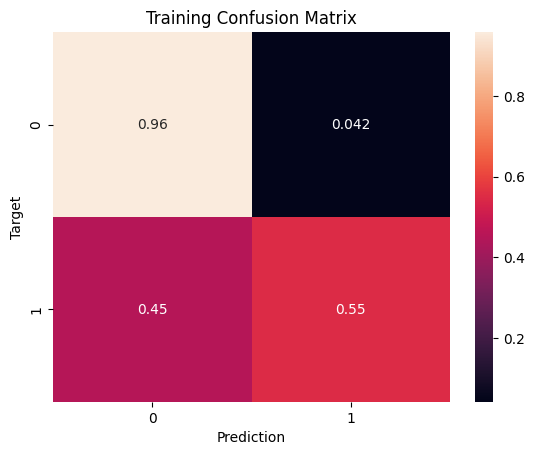

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 86.97%


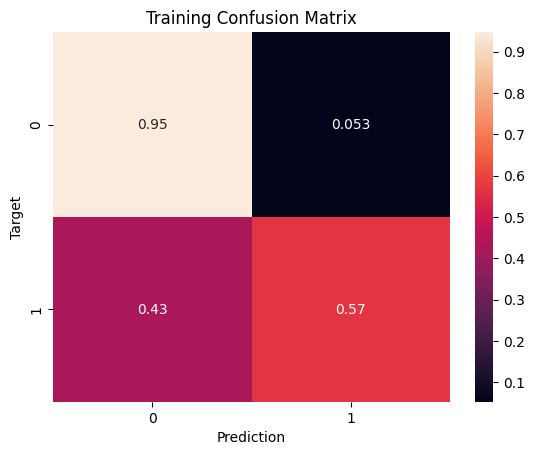

In [59]:
val_preds = predict_and_plot(X_val, val_targets, 'Training')

In [60]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1.0)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


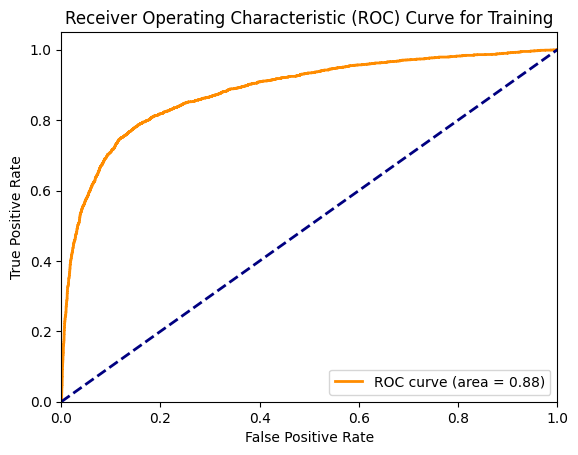

AUROC for Validation: 0.88


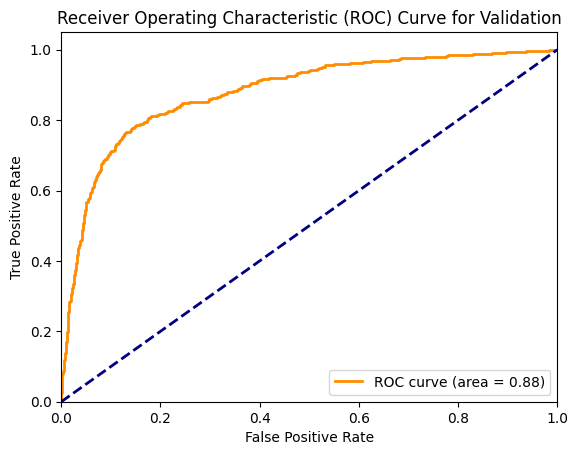

In [61]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [62]:
from sklearn.metrics import f1_score

train_predict_proba = model.predict_proba(X_train)[:, 1]
train_predict = (train_predict_proba >= 0.5).astype(int)

f1_test = f1_score(train_targets, train_predict, pos_label=1)


val_predict_proba = model.predict_proba(X_val)[:, 1]
val_predict = (val_predict_proba >= 0.5).astype(int)

f1_val = f1_score(val_targets, val_predict, pos_label=1)

print("F1 train with 0.5 ", f1_test)
print("F1 validation  0.5 ", f1_val)

F1 train with 0.5  0.6398852223816356
F1 validation  0.5  0.6389658356417359


**Висновок**\
модель — задовільна з потенціалом до покращення. Вона вже має стійку якість на тренуванні та валідації, без перенавчання. Також поріг 0.4 показує кращий результат 0.68 проти 0.64 приблизно

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [63]:
train_targets.value_counts()

,count
Exited,
0.0,9558
1.0,2442


In [64]:
majority_class = train_targets.mode()[0]

majority_predict_train = np.full_like(train_targets, fill_value=majority_class)
majority_predict_val = np.full_like(val_targets, fill_value=majority_class)

print("Accuracy (majority):", accuracy_score(val_targets, majority_predict_val))
print("F1 Score (majority):", f1_score(val_targets, majority_predict_val, pos_label=1))


Accuracy (majority): 0.7966666666666666
F1 Score (majority): 0.0


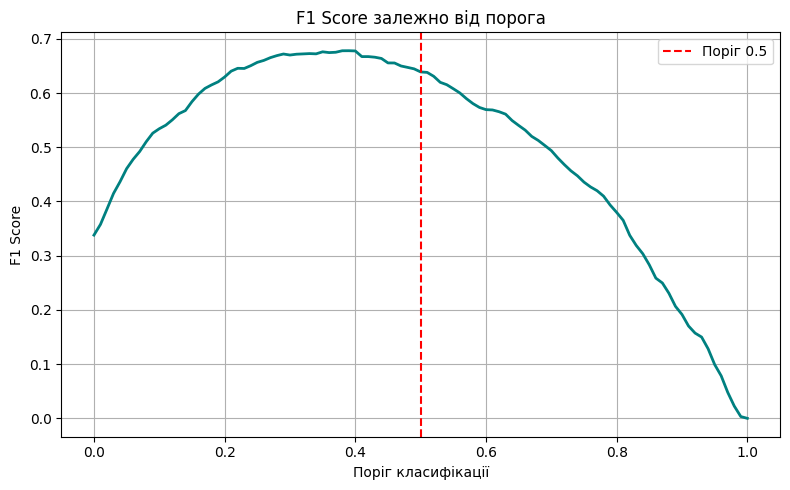

In [65]:
thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    y_pred = (val_predict_proba >= t).astype(int)
    score = f1_score(val_targets, y_pred)
    f1_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='teal', lw=2)
plt.title("F1 Score залежно від порога")
plt.xlabel("Поріг класифікації")
plt.ylabel("F1 Score")
plt.grid(True)
plt.axvline(x=0.5, color='red', linestyle='--', label='Поріг 0.5')
plt.legend()
plt.tight_layout()
plt.show()


In [66]:
best_f1 = max(f1_scores)
best_index = f1_scores.index(best_f1)
best_threshold = thresholds[best_index]

print(f"Найкращий поріг: {best_threshold:.2f}")
print(f"Максимальний F1 Score: {best_f1:.3f}")


Найкращий поріг: 0.39
Максимальний F1 Score: 0.678


**Висновок**\
модель вловлює клієнтів, які справді йдуть, і робить це стабільно на тренуванні та валідації. Значно перевещує якість моделі з мажоритарним класом\
Accuracy (majority): 0.7966666666666666\
F1 Score (majority): 0.0

accuracy_score(train) : 0.8745\
accuracy_score(validation) : 0.8696666666666667

F1 train with 0.5:   0.6398852223816356\
F1 validation  0.5:  0.6389658356417359

Найкращий поріг (train): 0.34\
Максимальний F1 Score (train): 0.678

Найкращий поріг (validation): 0.39\
Максимальний F1 Score (validation): 0.678

Accuracy ≈ 87% на train і validation свідчить про хорошу загальну точність\
F1 Score ≈ 0.64 при порозі 0.5 вказує на збалансоване врахування як precision, так і recall, навіть із типовим порогом\
Максимальний F1 ≈ 0.678 досягається при порогах 0.34 (train) і 0.39 (validation), що свідчить:  Нижчий поріг дозволяє краще “вловлювати” клієнтів, які дійсно йдуть, не занадто втрачаючи точність.

Модель має хорошу якість, але можна ще покращити.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [67]:
import joblib

In [103]:
bank_clients = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'numeric_columns': numeric_cols,
    'input_cols': X_train.columns.tolist(),
    'scaled_cols': ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
}


In [104]:
joblib.dump(bank_clients, 'bank_client.joblib')

['bank_client.joblib']

In [105]:
model_2 = joblib.load('bank_client.joblib')

In [106]:
test_pred = model_2['model'].predict(X_train)

In [107]:
accuracy_score(train_targets,test_pred)

0.8745

вау! працює,якість така сама як і у оригінальної моделі

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [108]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

def predict_raw_df(model, scaler, encoder, numeric_cols, scaled_cols, input_cols, input_df):
    input_df = input_df.copy()

    # 1. Перевірка на наявність 'Geography'
    if 'Geography' not in input_df.columns:
        raise ValueError(f"'Geography' відсутня у вхідному DataFrame. Є такі: {input_df.columns.tolist()}")

    # 2. Кодування 'Gender'
    input_df['Gender'] = (input_df['Gender'] == 'Male').astype(int)

    # 3. Масштабування тільки scaled_cols
    input_df[scaled_cols] = scaler.transform(input_df[scaled_cols])

    # 4. OneHot-кодування 'Geography'
    geo_encoded = encoder.transform(input_df[['Geography']])
    geo_cols = encoder.get_feature_names_out(['Geography'])
    geo_df = pd.DataFrame(geo_encoded, columns=geo_cols, index=input_df.index)

    # 5. Обʼєднання: числові фічі + бінарні + закодована Geography
    full_df = pd.concat([
        input_df[numeric_cols + ['Gender']],  # HasCrCard, IsActiveMember входять сюди
        geo_df
    ], axis=1)

    # 6. Перевірка, чи всі потрібні фічі присутні
    missing = [col for col in input_cols if col not in full_df.columns]
    if missing:
        raise ValueError(f"❗ Відсутні ознаки для моделі: {missing}")

    # 7. Впорядкування колонок для моделі
    X_input = full_df[input_cols]

    # 8. Повертаємо ймовірність класу 1
    return model.predict_proba(X_input)[:, 1]


In [74]:
test_df = pd.read_csv('drive/MyDrive/Colab Notebooks/test.csv')

In [75]:
test_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [109]:
probs = predict_raw_df(
    model=bank_clients['model'],
    scaler=bank_clients['scaler'],
    encoder=bank_clients['encoder'],
    numeric_cols=bank_clients['numeric_columns'],
    scaled_cols=bank_clients['scaled_cols'],
    input_cols=bank_clients['input_cols'],
    input_df=test_df
)


In [111]:
probs

array([0.06947787, 0.03336609, 0.15346609, ..., 0.01658439, 0.15203588,
       0.088052  ])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [114]:
test_df['Exited_prob'] = probs
test_df['Exited'] = (probs >= best_threshold).astype(int)
print(test_df['Exited'].value_counts())

Exited
0    7992
1    2008
Name: count, dtype: int64


In [116]:
test_df[['Exited_prob']].head()



,Exited_prob
0,0.069478
1,0.033366
2,0.153466
3,0.199320
4,0.054321


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [117]:
sample_submission = pd.read_csv('drive/MyDrive/Colab Notebooks/sample_submission.csv')

In [125]:
sample_submission['Exited'] = test_df['Exited'].values
sample_submission.to_csv('submission_log_reg.csv', index=False)

In [123]:
sample_submission[:5]


,id,Exited
0,15000,0
1,15001,0
2,15002,0
3,15003,0
4,15004,0


In [124]:
print(sample_submission['Exited'].value_counts())

Exited
0    7992
1    2008
Name: count, dtype: int64
